/tmp/ipykernel_2383/2659455415.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("AAPL", start="2020-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_2383/2659455415.py:28: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = df['Price'].resample('M').mean()
/tmp/ipykernel_2383/2659455415.py:45: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  yearly = df['Price'].resample('Y').mean()


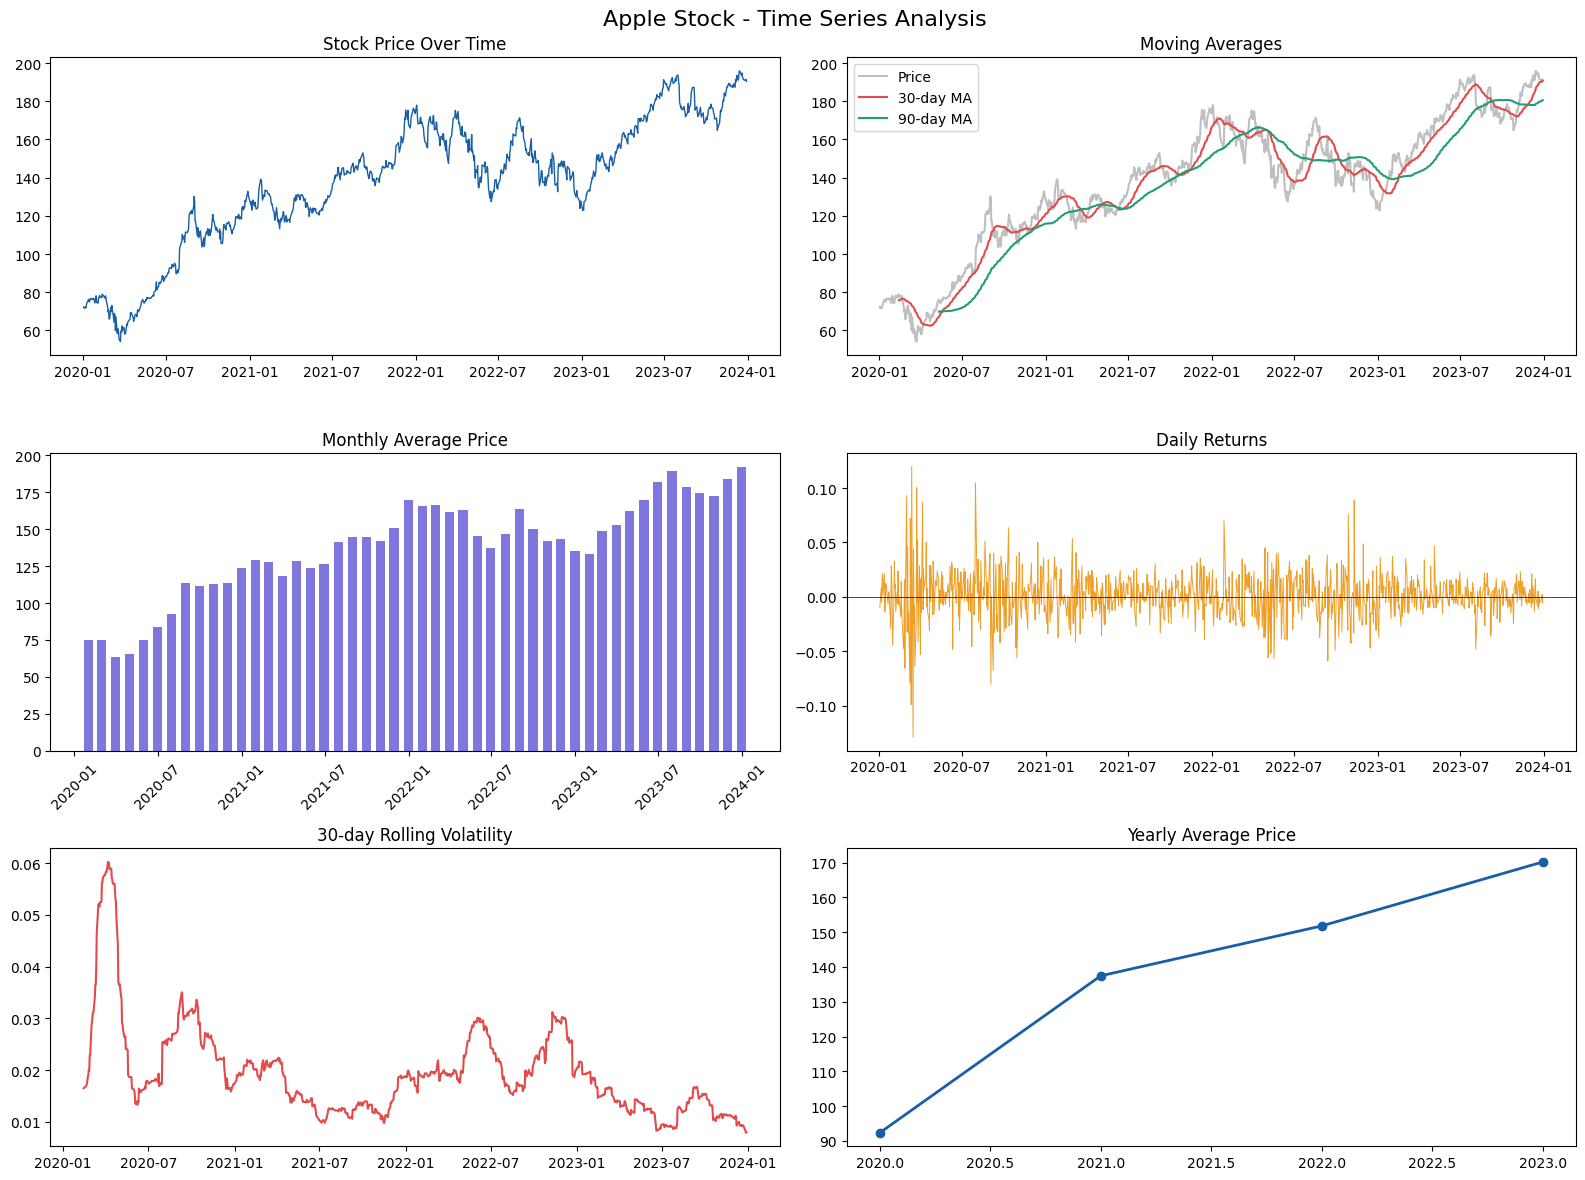

Start price: $72.33
End price:   $190.38
Avg daily return: 0.119%


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import yfinance as yf

print("Downloading stock data...")
df = yf.download("AAPL", start="2020-01-01", end="2024-01-01")
df = df[['Close']].copy()
df.columns = ['Price']

fig, axes = plt.subplots(3, 2, figsize=(16, 12))
fig.suptitle('Apple Stock - Time Series Analysis', fontsize=16)

# Raw price
axes[0,0].plot(df.index, df['Price'], color='#185FA5', linewidth=1)
axes[0,0].set_title('Stock Price Over Time')

# Moving averages
df['MA_30'] = df['Price'].rolling(30).mean()
df['MA_90'] = df['Price'].rolling(90).mean()
axes[0,1].plot(df['Price'], label='Price', alpha=0.5, color='gray')
axes[0,1].plot(df['MA_30'], label='30-day MA', color='#E24B4A')
axes[0,1].plot(df['MA_90'], label='90-day MA', color='#1D9E75')
axes[0,1].set_title('Moving Averages')
axes[0,1].legend()

# Monthly average
monthly = df['Price'].resample('M').mean()
axes[1,0].bar(monthly.index, monthly.values, color='#7F77DD', width=20)
axes[1,0].set_title('Monthly Average Price')
axes[1,0].tick_params(axis='x', rotation=45)

# Daily returns
df['Returns'] = df['Price'].pct_change()
axes[1,1].plot(df['Returns'], color='#EF9F27', linewidth=0.7)
axes[1,1].axhline(0, color='black', linewidth=0.5)
axes[1,1].set_title('Daily Returns')

# Volatility
df['Volatility'] = df['Returns'].rolling(30).std()
axes[2,0].plot(df['Volatility'], color='#E24B4A')
axes[2,0].set_title('30-day Rolling Volatility')

# Yearly trend
yearly = df['Price'].resample('Y').mean()
axes[2,1].plot(yearly.index.year, yearly.values, marker='o', color='#185FA5', linewidth=2)
axes[2,1].set_title('Yearly Average Price')

plt.tight_layout()
plt.savefig('timeseries_analysis.png', dpi=150)
plt.show()

print(f"Start price: ${df['Price'].iloc[0]:.2f}")
print(f"End price:   ${df['Price'].iloc[-1]:.2f}")
print(f"Avg daily return: {df['Returns'].mean()*100:.3f}%")